**Dataset Overview – California Housing**

The California Housing Dataset is a regression dataset containing housing information from California districts.

**Features (Independent Variables)**

* longitude – Longitude coordinate

* latitude – Latitude coordinate

* housing_median_age – Median age of houses in the district

* total_rooms – Total number of rooms in the district

* total_bedrooms – Total number of bedrooms in the district

* population – Total population of the district

* households – Total number of households

* median_income – Median income of households (in tens of thousands)

**Target (Dependent Variable)**

* median_house_value – Median house value (continuous)

**Mount Drive (Colab)**

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


**Dataset Loading and Inspection**

In [4]:
import pandas as pd

housing_data = pd.read_csv('/content/drive/My Drive/Datasets For ML/California Housing.csv')

print("Shape:", housing_data.shape)
print("Duplicated:", housing_data.duplicated().sum())
print("Missing Values:", housing_data.isnull().sum().sum())
print("First 2 rows:")
housing_data.head(2)

Shape: (20640, 9)
Duplicated: 0
Missing Values: 207
First 2 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500


**Data Preprocessing**

**1: Handle Missing Values**

In [5]:
housing_data['total_bedrooms'] = housing_data['total_bedrooms'].fillna(housing_data['total_bedrooms'].mean())

**2: Feature Scaling**

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = housing_data.drop('median_house_value', axis=1)
Y = housing_data['median_house_value']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Standardization improves convergence speed.

**Model Building – Manual Hyperparameter Tuning**

Since this is regression, use MLPRegressor().

**Tuned Parameters**

| Parameter          | Purpose              |
| ------------------ | -------------------- |
| hidden_layer_sizes | Hidden layer neurons |
| activation         | relu, tanh           |
| solver             | adam, sgd            |
| alpha              | L2 regularization    |
| learning_rate_init | Learning rate        |
| max_iter           | Epochs               |


**Model Implementation**

In [7]:
from sklearn.neural_network import MLPRegressor

mlp_reg = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

mlp_reg.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)

**Network Architecture**

* Input Layer: 8 neurons

* Hidden Layer 1: 128 (ReLU)

* Hidden Layer 2: 64 (ReLU)

* Output Layer: 1 neuron (Linear activation)

**For regression:**

* Final activation = Linear

* Loss function = Mean Squared Error (MSE)

**Model Evaluation**

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = mlp_reg.predict(X_test)

mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 4119798732.481504
RMSE: 64185.658308390855
MAE: 45173.06867917451
R2 Score: 0.6856096988886673


**Metric Interpretation**

* MSE: Average squared error

* RMSE: Error in original units

* MAE: Average absolute error

* R² Score: Proportion of variance explained

Typical R²: 0.60 – 0.85

**Prediction Interpretation**

In [9]:
sample = X_test[0].reshape(1, -1)

predicted_value = mlp_reg.predict(sample)

print("Predicted Median House Value:", predicted_value)
print("Actual Value:", Y_test[0])

Predicted Median House Value: [67352.42091862]
Actual Value: 452600


The output is a continuous value representing median house price (in $100,000s).

**Visualizing Predictions vs Actual**

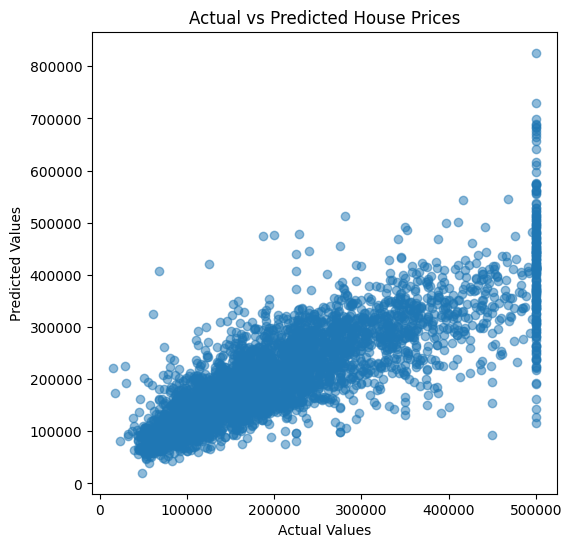

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(Y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")
plt.show()

If predictions are accurate, points lie close to the diagonal line.

**Inspecting Learned Weights**

In [11]:
print("Number of layers:", mlp_reg.n_layers_)
print("Number of outputs:", mlp_reg.n_outputs_)

print("Weight shapes:")
for w in mlp_reg.coefs_:
    print(w.shape)

Number of layers: 4
Number of outputs: 1
Weight shapes:
(8, 128)
(128, 64)
(64, 1)


**Conclusion**

The MLPRegressor successfully models nonlinear relationships in the California Housing dataset. After feature scaling and manual hyperparameter tuning, the network learns meaningful representations and achieves good regression performance as indicated by RMSE and R² metrics.

This demonstrates the application of MLP for both:

* Multi-class classification (MNIST)
* Regression (California Housing)

Further improvements can be achieved through deeper architectures, learning rate scheduling, or regularization tuning.
